# Fabric Defect Detection with GAN-based Data Augmentation

**Objective:** Enhance automated fabric inspection using GANs to address class imbalance through synthetic data augmentation.

**Pipeline Overview:**
1. Phase 1: Data Understanding & EDA
2. Phase 2: Data Preprocessing
3. Phase 3: Baseline Model Development
4. Phase 4: Model Evaluation
5. Phase 5: GAN Development
6. Phase 6: Model Improvement with GAN Data
7. Phase 7: Final Comparison & Statistical Testing

Let's start by setting up our environment and loading all necessary libraries.

## Setup: Import Libraries and Configure Environment

We'll import all necessary libraries for data processing, deep learning (PyTorch), GAN training, and evaluation.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import pickle
import json
import datetime
from pathlib import Path
import kagglehub # Added kagglehub

# Machine Learning and Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, precision_recall_fscore_support
)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import functional as F

# Random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directories
os.makedirs('results', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('callbacks', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('gan_samples', exist_ok=True)
os.makedirs('gan_models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/augmented', exist_ok=True)

print("✓ Environment setup complete!")

Using device: cuda
✓ Environment setup complete!


In [2]:
# This cell is now primarily for ensuring kagglehub is installed.
# kagglehub typically handles authentication via Colab's default credentials or doesn't require explicit kaggle.json setup.
import os
import sys

# Install kagglehub if not already installed
try:
    import kagglehub
except ImportError:
    %pip install kagglehub
    import kagglehub

print("✓ kagglehub is ready.")

✓ kagglehub is ready.


## Download and Extract Dataset

We'll download the dataset from Kaggle and extract it to the `data/Fabric Defects Dataset` directory.

In [3]:
# Define the Kaggle dataset identifier using the user's suggested dataset
kaggle_dataset_id = 'nexuswho/fabric-defects-dataset'

print(f"Downloading dataset '{kaggle_dataset_id}' using kagglehub...")

# kagglehub.dataset_download automatically downloads and extracts the dataset.
# It returns a Path object to the extracted dataset root directory.
try:
    download_path = kagglehub.dataset_download(kaggle_dataset_id)
    print(f"✓ Dataset downloaded to: {download_path}")

    # Verify the unzipped content and determine the actual data_path
    print("\nContent of downloaded directory:")
    !ls -F {download_path}

    # Assuming the structure is `download_path/Fabric Defects Dataset/Fabric Defect Dataset`
    # We need to find the correct nested path. Let's list a level deeper.
    !ls -F {download_path}/"Fabric Defects Dataset"/

    # Set the new data_path that will be used in subsequent cells
    new_data_path = Path(download_path) / 'Fabric Defects Dataset' / 'Fabric Defect Dataset'

    # Print the proposed data_path for confirmation
    print(f"\nProposed data_path for image loading: {new_data_path}")

    # Store the path for later use in other cells, like bd7e58fc
    # This global variable will be accessed by the next cell.
    global DATASET_ROOT_PATH
    DATASET_ROOT_PATH = new_data_path

except Exception as e:
    print(f"ERROR during dataset download: {e}")
    print("Please ensure you have network access and the dataset ID is correct.")
    sys.exit(1)


✓ Dataset downloaded to: /kaggle/input/datasets/nexuswho/fabric-defects-dataset

Content of downloaded directory:
'Fabric Defects Dataset'/
'Fabric Defect Dataset'/

Proposed data_path for image loading: /kaggle/input/datasets/nexuswho/fabric-defects-dataset/Fabric Defects Dataset/Fabric Defect Dataset


---
# Phase 1: Data Understanding & Exploratory Data Analysis (EDA)

In this phase, we'll:
- Load and inspect the fabric defect dataset
- Analyze class distribution
- Check image properties (size, channels, color space)
- Visualize sample images
- Identify data quality issues

This understanding is critical before any preprocessing or modeling.

## 1.1: Load and Inspect Dataset

We'll scan the dataset directory, load all image paths, and extract labels from folder names.

In [4]:
# Define dataset path. This will now use the globally set path after kagglehub download.
# Make sure DATASET_ROOT_PATH is set by the previous cell.
if 'DATASET_ROOT_PATH' in globals():
    data_path = DATASET_ROOT_PATH
else:
    # Fallback or error if DATASET_ROOT_PATH was not set (e.g., previous cell failed or not run)
    print("ERROR: DATASET_ROOT_PATH not found. Please run the dataset download cell first.")
    # Attempt a default if running this cell independently for testing, but ideally DATASET_ROOT_PATH is set.
    data_path = Path("data/Fabric Defects Dataset/Fabric Defect Dataset")


# Collect all image paths and labels
all_files = []
labels = []

for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                all_files.append(img_path)
                labels.append(class_name)

all_files = np.array(all_files)
labels = np.array(labels)

print(f"Total images: {len(all_files)}")
print(f"Total classes: {len(set(labels))}")
print(f"\nClass names: {sorted(set(labels))}")

Total images: 2739
Total classes: 6

Class names: [np.str_('Vertical'), np.str_('defect free'), np.str_('hole'), np.str_('horizontal'), np.str_('lines'), np.str_('stain')]


## 1.2: Analyze Class Distribution

Understanding class imbalance is crucial - this is what GANs will help us address.


Class Distribution:
Vertical            :  101 samples (  3.7%)
defect free         : 1666 samples ( 60.8%)
hole                :  281 samples ( 10.3%)
horizontal          :  136 samples (  5.0%)
lines               :  157 samples (  5.7%)
stain               :  398 samples ( 14.5%)
Imbalance Ratio: 16.50:1


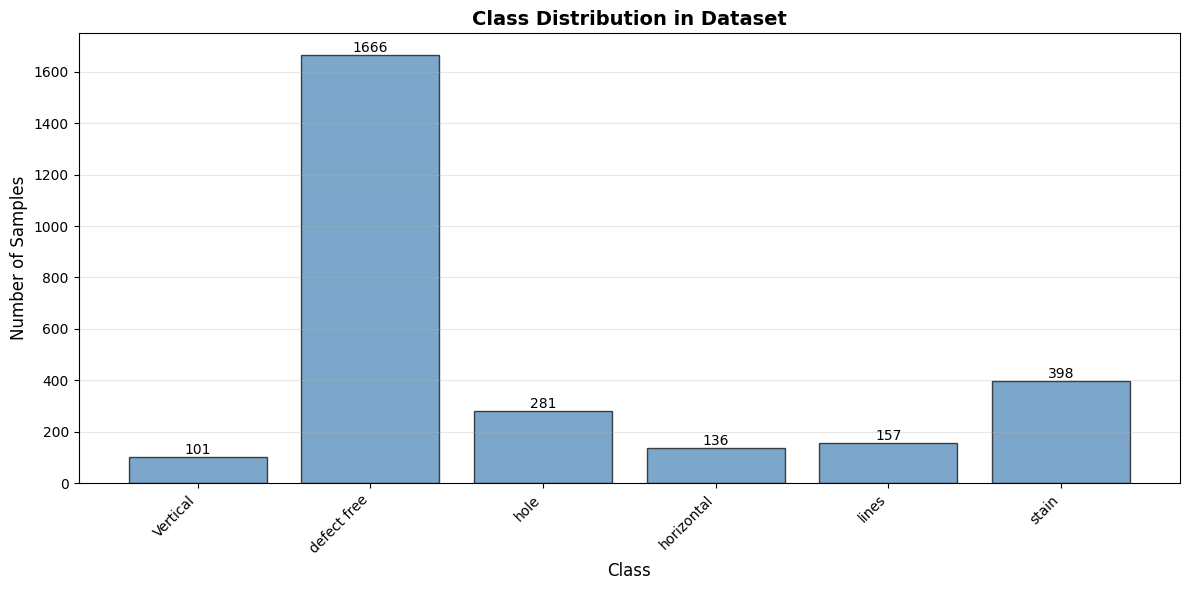


✓ Class distribution plot saved to results/class_distribution.png


In [5]:
# Count samples per class
class_counts = Counter(labels)

print("\nClass Distribution:")
print("=" * 50)
for class_name, count in sorted(class_counts.items()):
    percentage = (count / len(labels)) * 100
    print(f"{class_name:20s}: {count:4d} samples ({percentage:5.1f}%)")

# Calculate imbalance ratio
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print("=" * 50)
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualize distribution
plt.figure(figsize=(12, 6))
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
bars = plt.bar(classes, counts, color='steelblue', edgecolor='black', alpha=0.7)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=300)
plt.show()

print("\n✓ Class distribution plot saved to results/class_distribution.png")

## 1.3: Analyze Image Properties

Check image dimensions, color channels, and identify any inconsistencies.

In [6]:
# Sample images to check properties
widths = []
heights = []
channels = []
sample_size = min(100, len(all_files))

print(f"Analyzing properties of {sample_size} sample images...")

for img_path in all_files[:sample_size]:
    try:
        img = Image.open(img_path)
        widths.append(img.size[0])
        heights.append(img.size[1])
        channels.append(len(img.getbands()))
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

print("\nImage Properties:")
print("=" * 50)
print(f"Width range: {min(widths)} - {max(widths)} pixels")
print(f"Height range: {min(heights)} - {max(heights)} pixels")
print(f"Most common size: {Counter(zip(widths, heights)).most_common(1)[0]}")
print(f"Color channels: {Counter(channels)}")

# Check if all images are same size
if len(set(zip(widths, heights))) == 1:
    print(f"✓ All images have consistent size: {widths[0]}x{heights[0]}")
else:
    print(f"⚠ Images have varying sizes - will need resizing during preprocessing")

Analyzing properties of 100 sample images...

Image Properties:
Width range: 201 - 640 pixels
Height range: 264 - 360 pixels
Most common size: ((640, 360), 91)
Color channels: Counter({1: 77, 3: 23})
⚠ Images have varying sizes - will need resizing during preprocessing


## 1.4: Data Quality Checks

Identify corrupted images and potential issues.

In [7]:
# Check for corrupted images
corrupted = []
print("Checking for corrupted images...")

for img_path in all_files:
    try:
        img = Image.open(img_path)
        img.verify()  # Verify it's a valid image
    except Exception as e:
        corrupted.append(img_path)

if corrupted:
    print(f"⚠ Found {len(corrupted)} corrupted images:")
    for path in corrupted[:5]:  # Show first 5
        print(f"  - {path}")
else:
    print(f"✓ All {len(all_files)} images are valid!")

# Check for duplicate filenames
filenames = [os.path.basename(f) for f in all_files]
duplicates = [k for k, v in Counter(filenames).items() if v > 1]
if duplicates:
    print(f"⚠ Found {len(duplicates)} duplicate filenames")
else:
    print(f"✓ No duplicate filenames found")

Checking for corrupted images...
✓ All 2739 images are valid!
⚠ Found 170 duplicate filenames


## 1.5: Visual Inspection - Sample Images

Display sample images from each class to understand the defects visually.

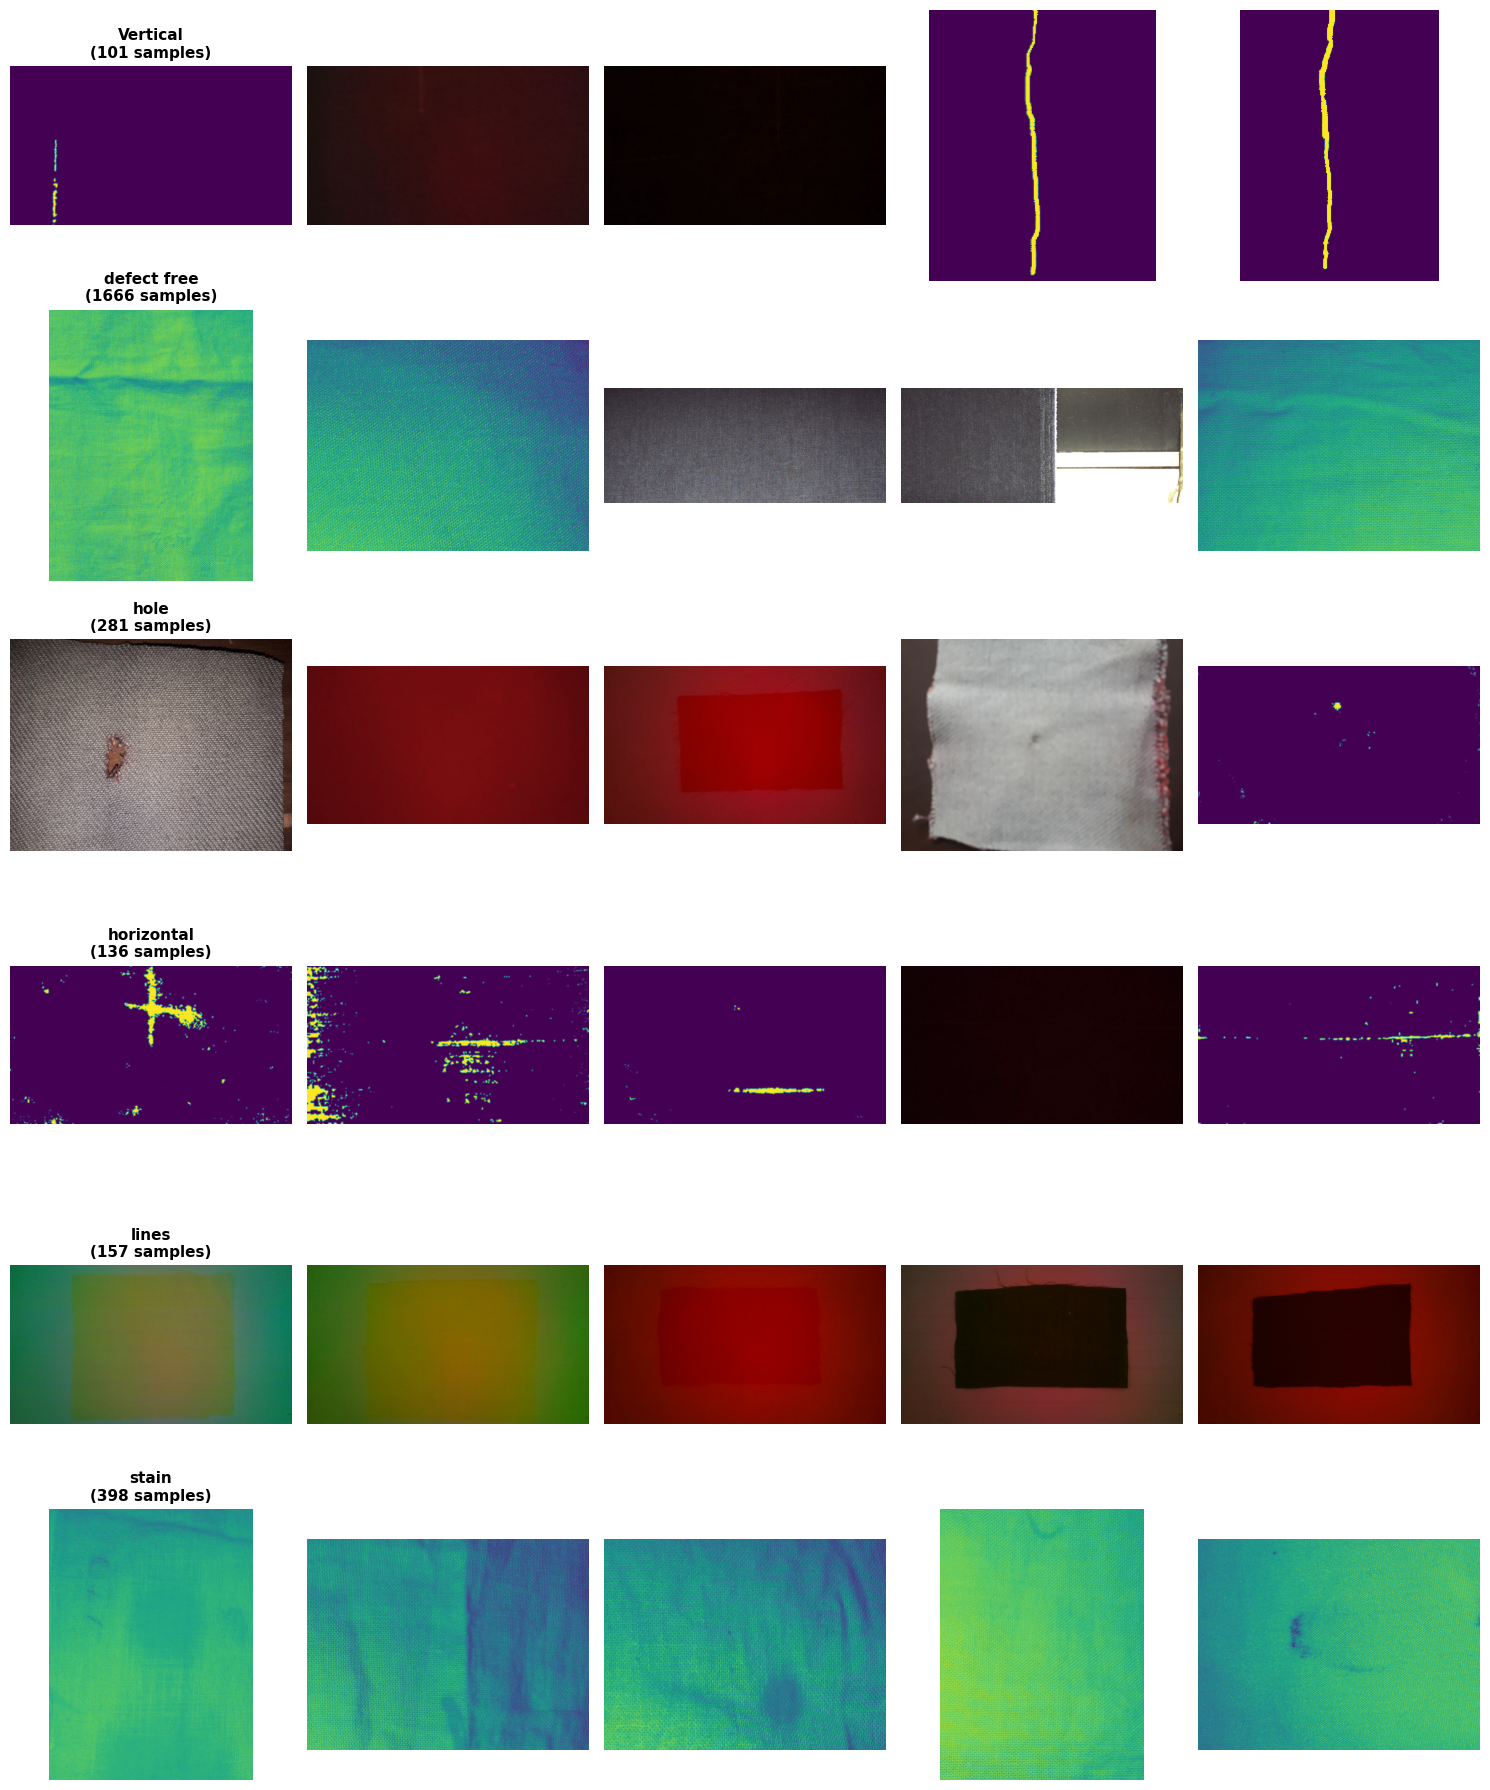

✓ Sample images visualization saved


In [8]:
import random

# Display sample images from each class
fig, axes = plt.subplots(len(class_counts), 5, figsize=(15, 3*len(class_counts)))

if len(class_counts) == 1:
    axes = axes.reshape(1, -1)

for i, class_name in enumerate(sorted(class_counts.keys())):
    # Get random samples from this class
    class_indices = np.where(labels == class_name)[0]
    sample_indices = np.random.choice(class_indices, min(5, len(class_indices)), replace=False)

    for j, idx in enumerate(sample_indices):
        img_path = all_files[idx]
        try:
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
        except:
            axes[i, j].text(0.5, 0.5, 'Error loading', ha='center', va='center')
            axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_title(f"{class_name}\n({class_counts[class_name]} samples)",
                                 fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=300)
plt.show()

print("✓ Sample images visualization saved")

---
# Phase 2: Data Preprocessing

In this phase, we'll:
- Split data into train/validation/test sets (80-10-10)
- Encode labels
- Create PyTorch datasets and data loaders
- Calculate class weights for handling imbalance
- Normalize and prepare images

**Critical Rule:** Always split BEFORE any augmentation or preprocessing!

## 2.1: Stratified Data Splitting

Split the data with stratification to maintain class distribution across all splits.

In [9]:
# Create arrays for splitting
X = np.array(all_files)
y = np.array(labels)

# First split: Train+Val vs Test (80-20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: Train vs Val (75-25 of remaining 80% = 60-20 of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 (20% of total)
    stratify=y_temp,
    random_state=42
)

print("Data Split Summary:")
print("=" * 60)
print(f"Train: {len(X_train):4d} samples ({len(X_train)/len(X)*100:5.1f}%)")
print(f"Val:   {len(X_val):4d} samples ({len(X_val)/len(X)*100:5.1f}%)")
print(f"Test:  {len(X_test):4d} samples ({len(X_test)/len(X)*100:5.1f}%)")
print("=" * 60)

# Verify stratification
print("\nVerifying stratification (train set):")
train_dist = Counter(y_train)
for class_name in sorted(train_dist.keys()):
    count = train_dist[class_name]
    pct = (count / len(y_train)) * 100
    original_pct = (class_counts[class_name] / len(y)) * 100
    print(f"{class_name:20s}: {count:3d} ({pct:5.1f}%) [original: {original_pct:5.1f}%]")

# Save splits for reproducibility
np.savez('data/processed/data_splits.npz',
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)

print("\n✓ Data splits saved to data/processed/data_splits.npz")

Data Split Summary:
Train: 1643 samples ( 60.0%)
Val:    548 samples ( 20.0%)
Test:   548 samples ( 20.0%)

Verifying stratification (train set):
Vertical            :  61 (  3.7%) [original:   3.7%]
defect free         : 999 ( 60.8%) [original:  60.8%]
hole                : 169 ( 10.3%) [original:  10.3%]
horizontal          :  82 (  5.0%) [original:   5.0%]
lines               :  94 (  5.7%) [original:   5.7%]
stain               : 238 ( 14.5%) [original:  14.5%]

✓ Data splits saved to data/processed/data_splits.npz


## 2.2: Label Encoding

Convert class names to integer indices for neural network training.

In [10]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Label Encoding Mapping:")
print("=" * 40)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

print(f"\nTotal classes: {num_classes}")

# Save encoder
with open('data/processed/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n✓ Label encoder saved")

Label Encoding Mapping:
0: Vertical
1: defect free
2: hole
3: horizontal
4: lines
5: stain

Total classes: 6

✓ Label encoder saved


## 2.3: Calculate Class Weights

Compute balanced class weights to handle the class imbalance during training.

In [11]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weight_dict = dict(enumerate(class_weights))

print("\nBalanced Class Weights:")
print("=" * 50)
for class_idx, weight in sorted(class_weight_dict.items()):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"{class_name:20s} (class {class_idx}): {weight:.4f}")

# Convert to tensor for PyTorch
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Save for later use
np.save('data/processed/class_weights.npy', class_weights)

print("\n✓ Class weights computed and saved")


Balanced Class Weights:
Vertical             (class 0): 4.4891
defect free          (class 1): 0.2741
hole                 (class 2): 1.6203
horizontal           (class 3): 3.3394
lines                (class 4): 2.9131
stain                (class 5): 1.1506

✓ Class weights computed and saved


## 2.4: PyTorch Dataset and DataLoader Setup

Create custom PyTorch Dataset class and DataLoaders for efficient batch processing.

In [12]:
# Define image transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Custom Dataset class
class FabricDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Create datasets
train_dataset = FabricDataset(X_train, y_train_encoded, transform=transform_train)
val_dataset = FabricDataset(X_val, y_val_encoded, transform=transform_val_test)
test_dataset = FabricDataset(X_test, y_test_encoded, transform=transform_val_test)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

print("\n✓ Preprocessing complete!")

DataLoaders created:
  Train batches: 52
  Val batches: 18
  Test batches: 18

✓ Preprocessing complete!


---
# Phase 3: Baseline Model Development

In this phase, we'll:
- Build a ResNet50 transfer learning model
- Compile with appropriate loss function and optimizer
- Train on the original (non-augmented) dataset
- Set up callbacks for monitoring and checkpointing

This baseline will be compared against the GAN-augmented model later.

## 3.1: ResNet50 Transfer Learning Model

Build a ResNet50 model with a custom classification head using PyTorch.

In [13]:
from torchvision import models

class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super(ResNet50Classifier, self).__init__()

        # Load pre-trained ResNet50
        self.backbone = models.resnet50(pretrained=True)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Replace final classification layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Create model
model = ResNet50Classifier(num_classes=num_classes, freeze_backbone=True)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Architecture: ResNet50 + Custom Head")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s] 


Model Architecture: ResNet50 + Custom Head
Total parameters: 24,034,118
Trainable parameters: 526,086
Device: cuda


## 3.2: Training Setup

Configure optimizer, loss function, and learning rate scheduler.

In [14]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

print("Training Configuration:")
print(f"  Loss function: CrossEntropyLoss (weighted)")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau")
print(f"  Batch size: {batch_size}")
print(f"  Device: {device}")

Training Configuration:
  Loss function: CrossEntropyLoss (weighted)
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau
  Batch size: 32
  Device: cuda


## 3.3: Training Loop with Validation

Train the baseline model with early stopping and checkpoint saving.

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Training parameters
num_epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting baseline model training...")
print("=" * 60)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Checkpoint saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/best_baseline_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Save final model
torch.save(model.state_dict(), 'models/baseline_model_final.pth')

print("=" * 60)
print("✓ Baseline model training complete!")

Starting baseline model training...
Epoch 5/50 | Train Loss: 0.6804, Acc: 84.78% | Val Loss: 0.5806, Acc: 86.86%
Epoch 10/50 | Train Loss: 0.4916, Acc: 88.80% | Val Loss: 0.5180, Acc: 88.32%
Epoch 15/50 | Train Loss: 0.4464, Acc: 90.20% | Val Loss: 0.5386, Acc: 87.59%
Epoch 20/50 | Train Loss: 0.4023, Acc: 90.51% | Val Loss: 0.5429, Acc: 88.14%

Early stopping at epoch 24
✓ Baseline model training complete!


## 3.4: Plot Training History

Visualize training and validation metrics.

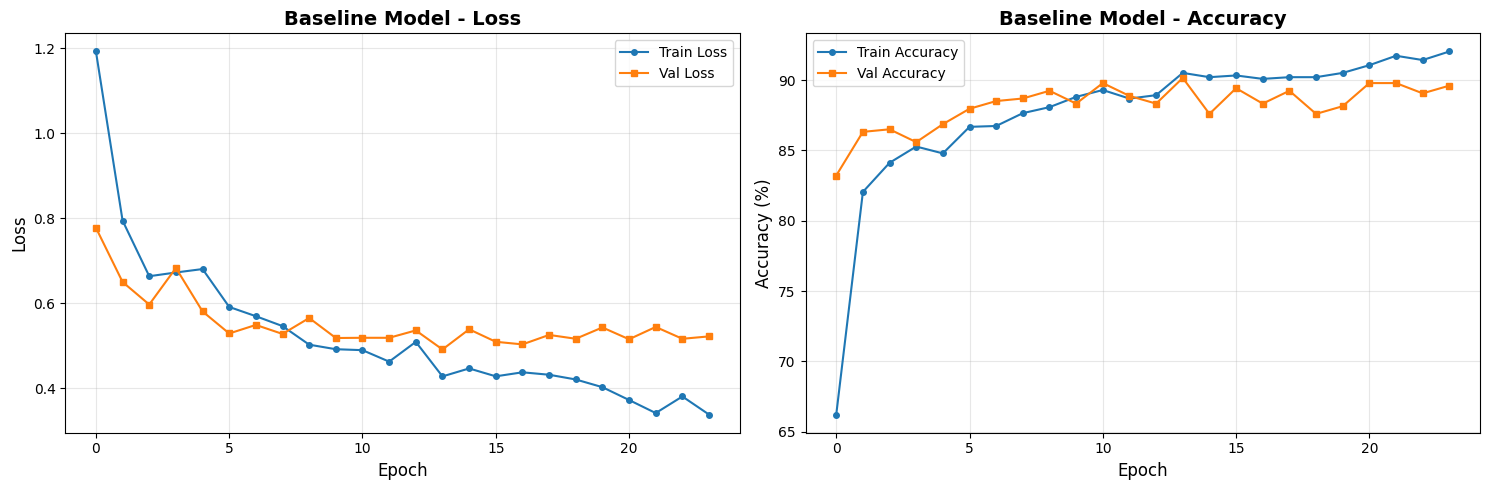

✓ Training history plot saved


In [16]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
ax1.plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Baseline Model - Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=4)
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Baseline Model - Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/baseline_training_history.png', dpi=300)
plt.show()

# Save history
with open('results/baseline_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("✓ Training history plot saved")

---
# Phase 4: Model Evaluation

In this phase, we'll:
- Load the best baseline model
- Generate predictions on the test set
- Calculate comprehensive evaluation metrics
- Create confusion matrices and detailed reports
- Analyze misclassifications

This establishes the baseline performance for comparison with GAN-augmented model.

## 4.1: Generate Predictions

Load the best model and generate predictions on the test set.

In [17]:
def predict_on_dataset(model, dataloader, device):
    """Generate predictions for a dataset"""
    model.eval()
    all_predictions = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_predictions.append(outputs.argmax(1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    predictions = np.concatenate(all_predictions, axis=0)
    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    return predictions, probs, labels

# Load best baseline model
model_baseline = ResNet50Classifier(num_classes=num_classes, freeze_backbone=True)
model_baseline.load_state_dict(torch.load('models/best_baseline_model.pth', map_location=device))
model_baseline = model_baseline.to(device)

print("Generating predictions on test set...")
y_pred_baseline, y_pred_probs_baseline, y_test_check = predict_on_dataset(
    model_baseline, test_loader, device
)

print(f"Predictions shape: {y_pred_probs_baseline.shape}")
print(f"Test set size: {len(y_test_encoded)}")
print("\n✓ Predictions generated")

Generating predictions on test set...
Predictions shape: (548, 6)
Test set size: 548

✓ Predictions generated


## 4.2: Calculate Overall Metrics

Compute accuracy, precision, recall, and F1-score for the baseline model.

In [19]:
# Overall metrics
accuracy_baseline = accuracy_score(y_test_encoded, y_pred_baseline)
precision_macro_baseline = precision_score(y_test_encoded, y_pred_baseline, average='macro')
recall_macro_baseline = recall_score(y_test_encoded, y_pred_baseline, average='macro')
f1_macro_baseline = f1_score(y_test_encoded, y_pred_baseline, average='macro')

print("\n" + "=" * 70)
print("BASELINE MODEL - OVERALL PERFORMANCE")
print("=" * 70)
print(f"Overall Accuracy:      {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"Macro Precision:       {precision_macro_baseline:.4f}")
print(f"Macro Recall:          {recall_macro_baseline:.4f}")
print(f"Macro F1-Score:        {f1_macro_baseline:.4f}")
print("=" * 70)


BASELINE MODEL - OVERALL PERFORMANCE
Overall Accuracy:      0.9033 (90.33%)
Macro Precision:       0.8041
Macro Recall:          0.7972
Macro F1-Score:        0.7835


## 4.3: Per-Class Metrics

Detailed metrics for each class - this is critical for understanding minority class performance.

In [21]:
# Detailed classification report
print("\nDetailed Classification Report:")
print("=" * 70)
report_baseline = classification_report(
    y_test_encoded, y_pred_baseline,
    target_names=label_encoder.classes_,
    digits=4
)
print(report_baseline)

# Save report
with open('results/baseline_classification_report.txt', 'w') as f:
    f.write("BASELINE MODEL CLASSIFICATION REPORT\n")
    f.write("=" * 70 + "\n")
    f.write(report_baseline)

# Per-class metrics in DataFrame
precision_bc, recall_bc, f1_bc, support_bc = precision_recall_fscore_support(
    y_test_encoded, y_pred_baseline
)

results_df_baseline = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_bc,
    'Recall': recall_bc,
    'F1-Score': f1_bc,
    'Support': support_bc
})

print("\nPer-Class Metrics Summary:")
print(results_df_baseline.to_string(index=False))

# Save to CSV
results_df_baseline.to_csv('results/baseline_per_class_metrics.csv', index=False)

print("\n✓ Metrics saved to CSV")


Detailed Classification Report:
              precision    recall  f1-score   support

    Vertical     0.9091    0.5000    0.6452        20
 defect free     0.9969    0.9610    0.9786       333
        hole     0.7556    0.6071    0.6733        56
  horizontal     0.6364    0.7778    0.7000        27
       lines     0.6667    0.9375    0.7792        32
       stain     0.8602    1.0000    0.9249        80

    accuracy                         0.9033       548
   macro avg     0.8041    0.7972    0.7835       548
weighted avg     0.9120    0.9033    0.9020       548


Per-Class Metrics Summary:
      Class  Precision   Recall  F1-Score  Support
   Vertical   0.909091 0.500000  0.645161       20
defect free   0.996885 0.960961  0.978593      333
       hole   0.755556 0.607143  0.673267       56
 horizontal   0.636364 0.777778  0.700000       27
      lines   0.666667 0.937500  0.779221       32
      stain   0.860215 1.000000  0.924855       80

✓ Metrics saved to CSV


## 4.4: Confusion Matrix Visualization

Create and visualize the confusion matrix to identify which classes are confused.

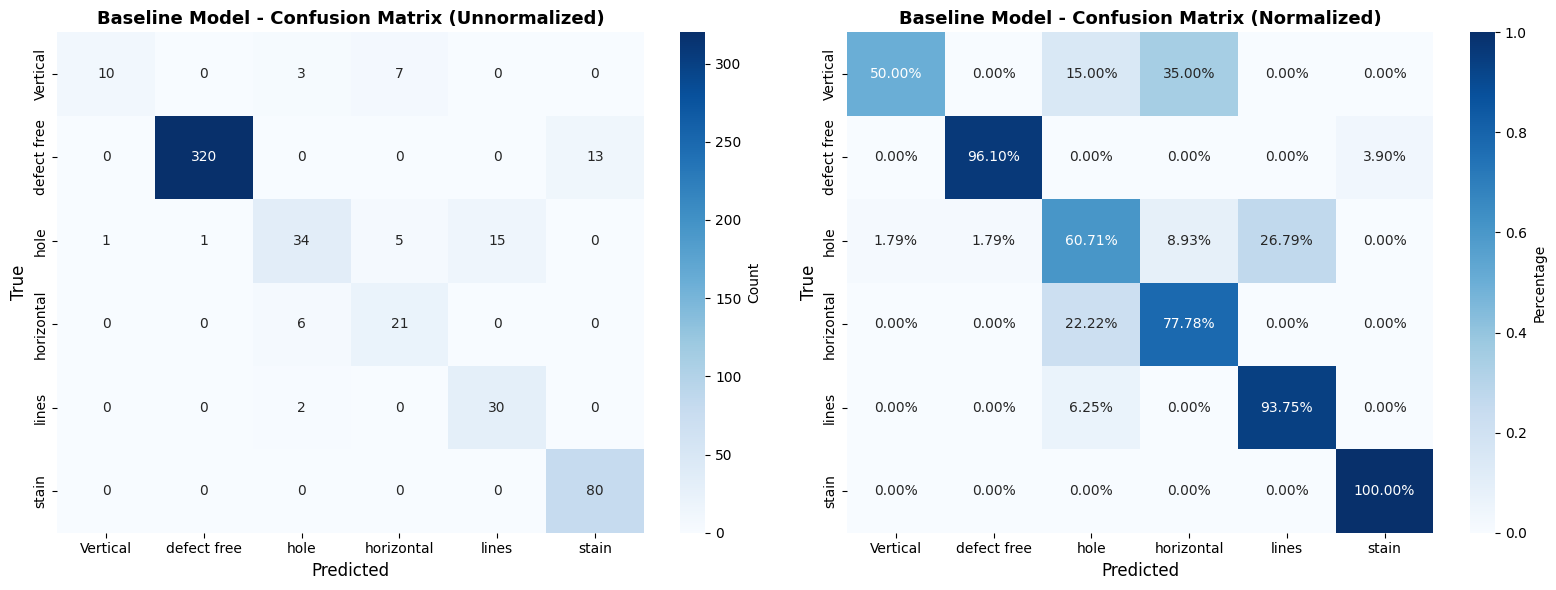

✓ Confusion matrix visualization saved


In [22]:
# Calculate confusion matrix
cm_baseline = confusion_matrix(y_test_encoded, y_pred_baseline)

# Visualize unnormalized
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Unnormalized confusion matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('Baseline Model - Confusion Matrix (Unnormalized)', fontsize=13, fontweight='bold')

# Normalized confusion matrix
cm_normalized = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, cbar_kws={'label': 'Percentage'})
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('True', fontsize=12)
ax2.set_title('Baseline Model - Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/baseline_confusion_matrix.png', dpi=300)
plt.show()

print("✓ Confusion matrix visualization saved")

## 4.5: Error Analysis

Identify and visualize misclassified samples to understand error patterns.

In [23]:
# Find misclassified samples
misclassified_indices = np.where(y_pred_baseline != y_test_encoded)[0]

print(f"\nError Analysis:")
print("=" * 60)
print(f"Total misclassified: {len(misclassified_indices)}/{len(y_test_encoded)}")
print(f"Error rate: {len(misclassified_indices)/len(y_test_encoded)*100:.2f}%")

# Analyze by class
print(f"\nMisclassifications by True Class:")
print("-" * 60)
for class_idx in range(num_classes):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    class_indices = np.where(y_test_encoded == class_idx)[0]
    class_errors = np.where((y_test_encoded == class_idx) & (y_pred_baseline != class_idx))[0]
    error_rate = len(class_errors) / len(class_indices) * 100 if len(class_indices) > 0 else 0
    print(f"{class_name:20s}: {len(class_errors):2d}/{len(class_indices):2d} errors ({error_rate:5.1f}%)")

print("\n✓ Error analysis complete")


Error Analysis:
Total misclassified: 53/548
Error rate: 9.67%

Misclassifications by True Class:
------------------------------------------------------------
Vertical            : 10/20 errors ( 50.0%)
defect free         : 13/333 errors (  3.9%)
hole                : 22/56 errors ( 39.3%)
horizontal          :  6/27 errors ( 22.2%)
lines               :  2/32 errors (  6.2%)
stain               :  0/80 errors (  0.0%)

✓ Error analysis complete


---
# Phase 5: GAN Development for Synthetic Data Generation

In this phase, we'll:
- Prepare defect-only datasets for each minority class
- Build DCGAN (Deep Convolutional GAN) architecture
- Train GANs for each defect type
- Generate synthetic images to balance the dataset
- Evaluate GAN quality

GANs will create realistic synthetic defect images to augment the minority classes.

## 5.1: Extract Defect-Only Images

Prepare training data for GAN by extracting images for each defect class.

In [24]:
def extract_class_images(X_paths, y_labels, target_class, label_encoder):
    """Extract all images for a specific class"""
    target_idx = label_encoder.transform([target_class])[0]
    class_indices = np.where(y_labels == target_idx)[0]
    class_paths = X_paths[class_indices]

    return class_paths

# Identify minority classes (non-defect-free)
normal_class = 'defect free'
defect_classes = [c for c in label_encoder.classes_ if c != normal_class]

print(f"Defect classes to augment: {defect_classes}")
print("\nExtracting defect-only images for GAN training...")
print("=" * 60)

for defect_class in defect_classes:
    defect_paths = extract_class_images(X_train, y_train_encoded, defect_class, label_encoder)
    np.save(f'data/processed/{defect_class}_paths.npy', defect_paths)
    print(f"{defect_class:20s}: {len(defect_paths):3d} images saved")

print("\n✓ Defect images extracted and saved")

Defect classes to augment: [np.str_('Vertical'), np.str_('hole'), np.str_('horizontal'), np.str_('lines'), np.str_('stain')]

Extracting defect-only images for GAN training...
Vertical            :  61 images saved
hole                : 169 images saved
horizontal          :  82 images saved
lines               :  94 images saved
stain               : 238 images saved

✓ Defect images extracted and saved


## 5.2: DCGAN Architecture - Generator

Build the generator network that creates fake images from random noise.

In [25]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=3):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim

        # First linear layer: latent_dim -> 7*7*256
        self.fc = nn.Linear(latent_dim, 7 * 7 * 256)

        # Convolutional layers with transposed convolutions
        self.main = nn.Sequential(
            # Input: 7x7x256
            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 14x14x128
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 28x28x64
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # 56x56x32
            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            # 112x112x16
            nn.ConvTranspose2d(16, img_channels, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()  # Output: 224x224x3, values in [-1, 1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 7, 7)
        x = self.main(x)
        return x

# Test generator
latent_dim = 100
generator_test = Generator(latent_dim=latent_dim)
z_test = torch.randn(1, latent_dim)
img_test = generator_test(z_test)

print(f"Generator Architecture:")
print(f"  Input: Random noise (batch, {latent_dim})")
print(f"  Output: Image tensor {tuple(img_test.shape)}")
print(f"  Output value range: [{img_test.min():.3f}, {img_test.max():.3f}]")
print("\n✓ Generator architecture verified")

Generator Architecture:
  Input: Random noise (batch, 100)
  Output: Image tensor (1, 3, 224, 224)
  Output value range: [-0.989, 0.963]

✓ Generator architecture verified


## 5.3: DCGAN Architecture - Discriminator

Build the discriminator network that distinguishes real from fake images.

In [26]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            # Input: 224x224x3
            nn.Conv2d(img_channels, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 112x112x64
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 56x56x128
            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 28x28x256
            nn.Conv2d(256, 512, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 14x14x512
            nn.Conv2d(512, 1024, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Flatten and classify
        self.fc = nn.Sequential(
            nn.Linear(1024 * 7 * 7, 1),
            nn.Sigmoid()  # Output: probability [0, 1]
        )

    def forward(self, x):
        x = self.main(x)
        x = x.reshape(x.size(0), -1) # Changed .view to .reshape
        x = self.fc(x)
        return x

# Test discriminator
discriminator_test = Discriminator()
img_test = torch.randn(1, 3, 224, 224)
output_test = discriminator_test(img_test)

print(f"Discriminator Architecture:")
print(f"  Input: Image tensor (batch, 3, 224, 224)")
print(f"  Output: Classification (batch, 1)")
print(f"  Output value range: [{output_test.min():.3f}, {output_test.max():.3f}]")
print("\n✓ Discriminator architecture verified")

Discriminator Architecture:
  Input: Image tensor (batch, 3, 224, 224)
  Output: Classification (batch, 1)
  Output value range: [0.480, 0.480]

✓ Discriminator architecture verified


## 5.4: Load Defect Images for GAN Training

Load and preprocess the defect images in normalized range [-1, 1] for GAN training.

In [27]:
def load_defect_images(defect_paths, target_size=(224, 224)):
    """Load defect images normalized to [-1, 1] for GAN training"""
    images = []

    for path in defect_paths:
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize(target_size, Image.BILINEAR)
            img_array = np.array(img, dtype=np.float32)

            # Normalize to [-1, 1]
            img_array = (img_array / 127.5) - 1.0
            images.append(img_array)
        except Exception as e:
            print(f"Error loading {path}: {e}")

    return np.array(images)

# Example: Load one defect class
if len(defect_classes) > 0:
    example_class = defect_classes[0]
    example_paths = np.load(f'data/processed/{example_class}_paths.npy')
    example_images = load_defect_images(example_paths)

    print(f"Example: Loaded {len(example_images)} images from class '{example_class}'")
    print(f"  Shape: {example_images.shape}")
    print(f"  Value range: [{example_images.min():.3f}, {example_images.max():.3f}]")
    print("\n✓ Image loading pipeline verified")

Example: Loaded 61 images from class 'Vertical'
  Shape: (61, 224, 224, 3)
  Value range: [-1.000, 1.000]

✓ Image loading pipeline verified


## 5.5: GAN Training Function

Define the training loop that trains generator and discriminator alternately.

In [28]:
def train_gan(generator, discriminator, real_images, defect_class,
              epochs=500, batch_size=32, latent_dim=100, device='cpu'):
    """
    Train GAN for a specific defect class.

    Args:
        generator: Generator model
        discriminator: Discriminator model
        real_images: Array of real defect images (normalized to [-1, 1])
        defect_class: Name of defect class (for saving)
        epochs: Number of training epochs
        batch_size: Batch size
        latent_dim: Latent dimension
        device: 'cpu' or 'cuda'
    """
    # Move models to device
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    # Optimizers
    lr = 0.0002
    betas = (0.5, 0.999)
    optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    # Loss function
    criterion = nn.BCELoss()

    # Create directories
    os.makedirs(f'gan_samples/{defect_class}', exist_ok=True)
    os.makedirs(f'gan_models/{defect_class}', exist_ok=True)

    # Training history
    d_losses = []
    g_losses = []

    # Prepare data
    real_images_tensor = torch.FloatTensor(real_images).permute(0, 3, 1, 2) / 255.0  # Convert to [0, 1]
    real_images_tensor = real_images_tensor * 2 - 1  # Convert to [-1, 1]

    num_batches = len(real_images_tensor) // batch_size

    print(f"\n{'='*70}")
    print(f"Training GAN for defect class: {defect_class}")
    print(f"{'='*70}")
    print(f"Real images: {real_images_tensor.shape}")
    print(f"Epochs: {epochs}, Batches per epoch: {num_batches}")
    print(f"Batch size: {batch_size}, Latent dim: {latent_dim}")

    for epoch in range(epochs):
        epoch_d_loss = []
        epoch_g_loss = []

        # Shuffle data
        indices = torch.randperm(len(real_images_tensor))
        real_images_shuffled = real_images_tensor[indices]

        for batch_idx in range(num_batches):
            # Get real batch
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            real_batch = real_images_shuffled[start_idx:end_idx].to(device)

            current_batch_size = real_batch.size(0)

            # Labels
            real_labels = torch.ones((current_batch_size, 1), device=device)
            fake_labels = torch.zeros((current_batch_size, 1), device=device)

            # ===== Train Discriminator =====
            # Train on real images
            optimizer_d.zero_grad()
            real_output = discriminator(real_batch)
            d_loss_real = criterion(real_output, real_labels)

            # Train on fake images
            z = torch.randn((current_batch_size, latent_dim), device=device)
            fake_batch = generator(z)
            fake_output = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_output, fake_labels)

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_d.step()

            # ===== Train Generator =====
            optimizer_g.zero_grad()
            z = torch.randn((current_batch_size, latent_dim), device=device)
            fake_batch = generator(z)
            fake_output = discriminator(fake_batch)

            # Generator wants discriminator to output 1 (thinks it's real)
            g_loss = criterion(fake_output, real_labels)
            g_loss.backward()
            optimizer_g.step()

            epoch_d_loss.append(d_loss.item())
            epoch_g_loss.append(g_loss.item())

        # Average losses for this epoch
        avg_d_loss = np.mean(epoch_d_loss)
        avg_g_loss = np.mean(epoch_g_loss)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        # Print progress
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

        # Save samples
        if (epoch + 1) % 100 == 0:
            generator.eval()
            with torch.no_grad():
                z = torch.randn((16, latent_dim), device=device)
                fake_images = generator(z)
                fake_images = (fake_images + 1) / 2  # Convert to [0, 1]

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for i, ax in enumerate(axes.ravel()):
                img = fake_images[i].cpu().permute(1, 2, 0).numpy()
                ax.imshow(img)
                ax.axis('off')
            plt.suptitle(f'{defect_class} - Epoch {epoch+1}', fontsize=12)
            plt.tight_layout()
            plt.savefig(f'gan_samples/{defect_class}/generated_epoch_{epoch+1}.png', dpi=100)
            plt.close()
            generator.train()

    # Save final models
    torch.save(generator.state_dict(), f'gan_models/{defect_class}/generator_final.pth')
    torch.save(discriminator.state_dict(), f'gan_models/{defect_class}/discriminator_final.pth')

    print(f"\n✓ GAN training completed for {defect_class}")

    return d_losses, g_losses

print("✓ GAN training function defined")

✓ GAN training function defined


## 5.6: Train GANs for All Defect Classes

Train a separate GAN for each defect type to generate realistic synthetic images.

In [29]:
# Store GAN models and training history
gan_models = {}
gan_histories = {}

# Train GAN for each defect class
for defect_class in defect_classes:
    print(f"\nProcessing class: {defect_class}")

    # Load defect images
    defect_paths = np.load(f'data/processed/{defect_class}_paths.npy')
    real_images = load_defect_images(defect_paths)

    # Create fresh models
    generator = Generator(latent_dim=latent_dim)
    discriminator = Discriminator()

    # Train
    d_losses, g_losses = train_gan(
        generator, discriminator, real_images,
        defect_class=defect_class,
        epochs=300,  # Reduced for demonstration (typically 500-1000)
        batch_size=16,
        latent_dim=latent_dim,
        device=device
    )

    gan_models[defect_class] = generator
    gan_histories[defect_class] = {'d_losses': d_losses, 'g_losses': g_losses}

    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Discriminator Loss', linewidth=2)
    plt.plot(g_losses, label='Generator Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'GAN Training History - {defect_class}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'gan_samples/{defect_class}/training_history.png', dpi=300)
    plt.close()

    print(f"\u2713 GAN training completed and history saved for {defect_class}")

print("\n" + "="*70)
print("\u2713 All GAN models trained successfully!")
print("="*70)


Processing class: Vertical

Training GAN for defect class: Vertical
Real images: torch.Size([61, 3, 224, 224])
Epochs: 300, Batches per epoch: 3
Batch size: 16, Latent dim: 100
Epoch  50/300 | D Loss: 100.0000 | G Loss: 0.0000
Epoch 100/300 | D Loss: 100.0000 | G Loss: 0.0000
Epoch 150/300 | D Loss: 100.0000 | G Loss: 0.0000
Epoch 200/300 | D Loss: 100.0000 | G Loss: 0.0000
Epoch 250/300 | D Loss: 100.0000 | G Loss: 0.0000
Epoch 300/300 | D Loss: 100.0000 | G Loss: 0.0000

✓ GAN training completed for Vertical
✓ GAN training completed and history saved for Vertical

Processing class: hole

Training GAN for defect class: hole
Real images: torch.Size([169, 3, 224, 224])
Epochs: 300, Batches per epoch: 10
Batch size: 16, Latent dim: 100
Epoch  50/300 | D Loss: 1.6358 | G Loss: 1.7000
Epoch 100/300 | D Loss: 0.8712 | G Loss: 1.8143
Epoch 150/300 | D Loss: 1.1415 | G Loss: 1.1415
Epoch 200/300 | D Loss: 1.4834 | G Loss: 1.1020
Epoch 250/300 | D Loss: 1.4214 | G Loss: 0.9027
Epoch 300/300 |

## 5.7: Generate Synthetic Dataset

Use trained GANs to generate synthetic images and augment the training dataset.

In [30]:
def generate_synthetic_dataset(generator, n_samples, latent_dim, defect_class,
                               save_dir='data/augmented', device='cpu'):
    """
    Generate and save synthetic images.

    Args:
        generator: Trained generator model
        n_samples: Number of synthetic images to generate
        latent_dim: Latent dimension
        defect_class: Class name for saving
        save_dir: Directory to save images
        device: 'cpu' or 'cuda'
    """
    # Create directory
    class_dir = os.path.join(save_dir, defect_class)
    os.makedirs(class_dir, exist_ok=True)

    generator = generator.to(device)
    generator.eval()

    print(f"\nGenerating {n_samples} synthetic images for class '{defect_class}'...")

    generated_paths = []
    batch_size = 32

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch_n = min(batch_size, n_samples - i)

            # Generate images
            z = torch.randn((batch_n, latent_dim), device=device)
            generated_images = generator(z)

            # Convert to [0, 255]
            generated_images = ((generated_images + 1) / 2.0 * 255).byte()
            generated_images = generated_images.cpu().numpy()

            # Save images
            for j, img_array in enumerate(generated_images):
                img_idx = i + j
                img_path = os.path.join(class_dir, f'synthetic_{img_idx:04d}.png')

                # Transpose from (C, H, W) to (H, W, C)
                img_array = np.transpose(img_array, (1, 2, 0))
                img = Image.fromarray(img_array)
                img.save(img_path)
                generated_paths.append(img_path)

            if (i + batch_n) % 100 == 0:
                print(f"  Generated {i + batch_n}/{n_samples} images...")

    print(f"✓ Saved {len(generated_paths)} synthetic images to {class_dir}")

    # Save paths
    np.save(os.path.join(save_dir, f'{defect_class}_synthetic_paths.npy'),
            np.array(generated_paths))

    return generated_paths

# Generate synthetic images for each defect class
# Rule: Generate 2-3x the original count to balance classes
synthetic_paths_dict = {}

for defect_class in defect_classes:
    # Load generator
    generator = Generator(latent_dim=latent_dim)
    generator.load_state_dict(torch.load(f'gan_models/{defect_class}/generator_final.pth',
                                         map_location=device))

    # Determine how many to generate
    original_count = len(np.load(f'data/processed/{defect_class}_paths.npy'))
    synthetic_count = original_count * 2  # 2x augmentation

    # Generate
    synthetic_paths = generate_synthetic_dataset(
        generator, synthetic_count, latent_dim, defect_class,
        save_dir='data/augmented', device=device
    )

    synthetic_paths_dict[defect_class] = synthetic_paths

print("\n" + "="*70)
print("✓ Synthetic dataset generation complete!")
print("="*70)


Generating 122 synthetic images for class 'Vertical'...
✓ Saved 122 synthetic images to data/augmented/Vertical

Generating 338 synthetic images for class 'hole'...
✓ Saved 338 synthetic images to data/augmented/hole

Generating 164 synthetic images for class 'horizontal'...
✓ Saved 164 synthetic images to data/augmented/horizontal

Generating 188 synthetic images for class 'lines'...
✓ Saved 188 synthetic images to data/augmented/lines

Generating 476 synthetic images for class 'stain'...
✓ Saved 476 synthetic images to data/augmented/stain

✓ Synthetic dataset generation complete!


---
# Phase 6: Model Improvement with GAN-Augmented Data

In this phase, we'll:
- Combine original training data with synthetic data
- Recalculate class weights based on augmented dataset
- Train a new CNN with the balanced dataset
- Compare performance with baseline model

This demonstrates the benefit of GAN-based augmentation for minority classes.

## 6.1: Combine Original and Synthetic Data

Merge original training data with synthetic data to create an augmented training set.

In [31]:
def combine_datasets(original_train_paths, original_train_labels,
                     synthetic_base_dir='data/augmented', label_encoder=None):
    """Combine original and synthetic datasets"""
    combined_paths = list(original_train_paths)
    combined_labels = list(original_train_labels)

    # Decode original labels for matching
    original_labels_str = label_encoder.inverse_transform(original_train_labels)
    combined_labels_str = list(original_labels_str)

    print("Combining original and synthetic datasets...")
    print("=" * 60)

    # Get all synthetic classes
    for defect_class in os.listdir(synthetic_base_dir):
        class_dir = os.path.join(synthetic_base_dir, defect_class)

        if not os.path.isdir(class_dir):
            continue

        # Load synthetic paths
        synthetic_paths_file = os.path.join(synthetic_base_dir, f'{defect_class}_synthetic_paths.npy')
        if os.path.exists(synthetic_paths_file):
            synthetic_images = np.load(synthetic_paths_file)
            combined_paths.extend(synthetic_images)
            combined_labels_str.extend([defect_class] * len(synthetic_images))

            print(f"{defect_class:20s}: +{len(synthetic_images):4d} synthetic images")

    combined_paths = np.array(combined_paths)
    combined_labels_str = np.array(combined_labels_str)
    combined_labels_encoded = label_encoder.transform(combined_labels_str)

    print("=" * 60)
    print(f"Original training samples: {len(original_train_paths):5d}")
    print(f"Synthetic samples added:   {len(combined_paths) - len(original_train_paths):5d}")
    print(f"Augmented dataset total:   {len(combined_paths):5d}")
    print("=" * 60)

    return combined_paths, combined_labels_encoded

# Combine datasets
X_train_augmented, y_train_augmented_encoded = combine_datasets(
    X_train, y_train_encoded, synthetic_base_dir='data/augmented', label_encoder=label_encoder
)

# Verify new distribution
print("\nAugmented Class Distribution:")
print("=" * 50)
augmented_dist = Counter(y_train_augmented_encoded)
for class_idx in sorted(augmented_dist.keys()):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    count = augmented_dist[class_idx]
    pct = (count / len(y_train_augmented_encoded)) * 100
    print(f"{class_name:20s}: {count:5d} ({pct:5.1f}%)")
print("=" * 50)

Combining original and synthetic datasets...
horizontal          : + 164 synthetic images
hole                : + 338 synthetic images
stain               : + 476 synthetic images
Vertical            : + 122 synthetic images
lines               : + 188 synthetic images
Original training samples:  1643
Synthetic samples added:    1288
Augmented dataset total:    2931

Augmented Class Distribution:
Vertical            :   183 (  6.2%)
defect free         :   999 ( 34.1%)
hole                :   507 ( 17.3%)
horizontal          :   246 (  8.4%)
lines               :   282 (  9.6%)
stain               :   714 ( 24.4%)


## 6.2: Recalculate Class Weights

Compute new class weights for the augmented dataset.

In [32]:
# Calculate new class weights
class_weights_augmented = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_augmented_encoded),
    y=y_train_augmented_encoded
)

class_weight_dict_augmented = dict(enumerate(class_weights_augmented))
class_weights_tensor_augmented = torch.FloatTensor(class_weights_augmented).to(device)

print("\nUpdated Class Weights (Augmented Dataset):")
print("=" * 50)
for class_idx, weight in sorted(class_weight_dict_augmented.items()):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    original_weight = class_weight_dict[class_idx]
    change = weight / original_weight
    print(f"{class_name:20s}: {weight:.4f} (was {original_weight:.4f}, {change:.2f}x)")
print("=" * 50)


Updated Class Weights (Augmented Dataset):
Vertical            : 2.6694 (was 4.4891, 0.59x)
defect free         : 0.4890 (was 0.2741, 1.78x)
hole                : 0.9635 (was 1.6203, 0.59x)
horizontal          : 1.9858 (was 3.3394, 0.59x)
lines               : 1.7323 (was 2.9131, 0.59x)
stain               : 0.6842 (was 1.1506, 0.59x)


## 6.3: Create Augmented Data Loaders

Build new data loaders with the augmented dataset.

In [33]:
# Create augmented dataset
train_dataset_augmented = FabricDataset(
    X_train_augmented, y_train_augmented_encoded,
    transform=transform_train
)

# Create data loader
train_loader_augmented = DataLoader(
    train_dataset_augmented, batch_size=batch_size, shuffle=True, num_workers=0
)

print(f"Augmented Training DataLoader:")
print(f"  Total samples: {len(train_dataset_augmented)}")
print(f"  Batch size: {batch_size}")
print(f"  Batches: {len(train_loader_augmented)}")
print(f"  Validation and test loaders remain unchanged")

Augmented Training DataLoader:
  Total samples: 2931
  Batch size: 32
  Batches: 92
  Validation and test loaders remain unchanged


## 6.4: Train Enhanced CNN with GAN Data

Train a new model using the GAN-augmented dataset.

In [34]:
# Create new model for GAN-augmented training
model_gan = ResNet50Classifier(num_classes=num_classes, freeze_backbone=True)
model_gan = model_gan.to(device)

# Loss and optimizer
criterion_gan = nn.CrossEntropyLoss(weight=class_weights_tensor_augmented)
optimizer_gan = optim.Adam(model_gan.parameters(), lr=0.001, betas=(0.9, 0.999))
scheduler_gan = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gan, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

# Training
num_epochs_gan = 50
best_val_loss_gan = float('inf')
patience = 10
patience_counter = 0
history_gan = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\nStarting GAN-augmented model training...")
print("=" * 60)

for epoch in range(num_epochs_gan):
    train_loss, train_acc = train_epoch(model_gan, train_loader_augmented, criterion_gan, optimizer_gan, device)
    val_loss, val_acc = validate_epoch(model_gan, val_loader, criterion_gan, device)

    history_gan['train_loss'].append(train_loss)
    history_gan['val_loss'].append(val_loss)
    history_gan['train_acc'].append(train_acc)
    history_gan['val_acc'].append(val_acc)

    scheduler_gan.step(val_loss)

    # Checkpoint saving
    if val_loss < best_val_loss_gan:
        best_val_loss_gan = val_loss
        torch.save(model_gan.state_dict(), 'models/best_gan_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs_gan} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Save final model
torch.save(model_gan.state_dict(), 'models/gan_augmented_model_final.pth')

print("=" * 60)
print("✓ GAN-augmented model training complete!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting GAN-augmented model training...
Epoch 5/50 | Train Loss: 0.2595, Acc: 92.12% | Val Loss: 0.5529, Acc: 87.96%
Epoch 10/50 | Train Loss: 0.2105, Acc: 92.94% | Val Loss: 0.4652, Acc: 88.14%
Epoch 15/50 | Train Loss: 0.1881, Acc: 93.59% | Val Loss: 0.4791, Acc: 90.88%
Epoch 20/50 | Train Loss: 0.1500, Acc: 94.64% | Val Loss: 0.4232, Acc: 89.96%
Epoch 25/50 | Train Loss: 0.1307, Acc: 95.63% | Val Loss: 0.4425, Acc: 90.69%
Epoch 30/50 | Train Loss: 0.1179, Acc: 95.80% | Val Loss: 0.5239, Acc: 90.15%

Early stopping at epoch 30
✓ GAN-augmented model training complete!


## 6.5: Plot Comparison of Training Histories

Visualize baseline vs GAN-augmented training curves.

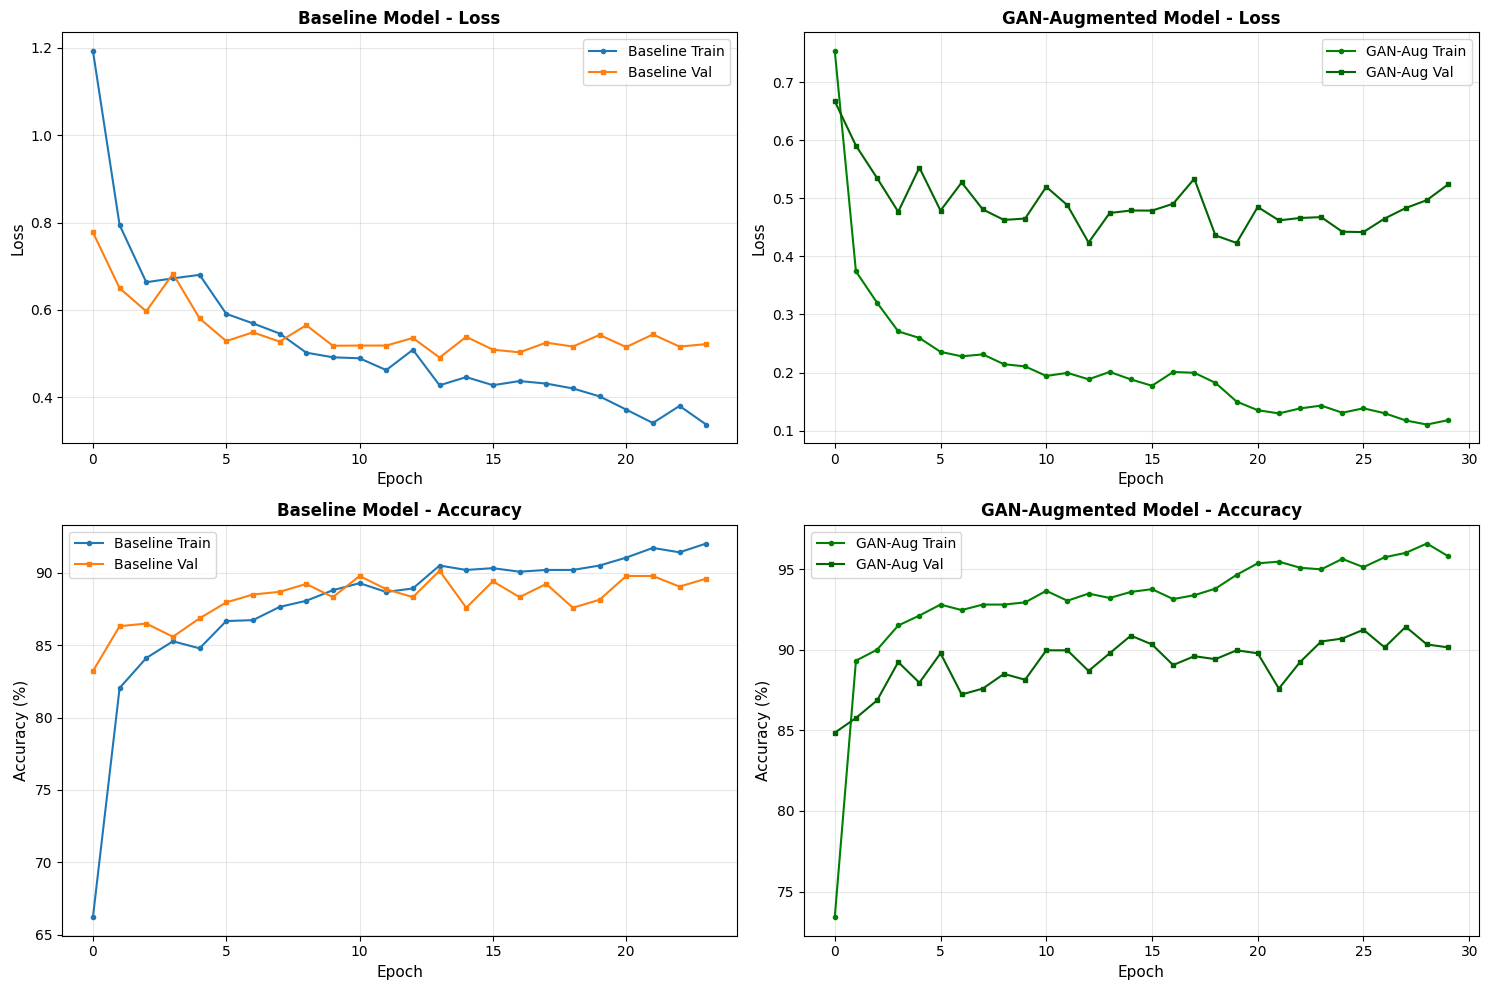

✓ Training comparison plot saved


In [35]:
# Compare training histories
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss comparison
ax1.plot(history['train_loss'], label='Baseline Train', marker='o', markersize=3)
ax1.plot(history['val_loss'], label='Baseline Val', marker='s', markersize=3)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Baseline Model - Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(history_gan['train_loss'], label='GAN-Aug Train', marker='o', markersize=3, color='green')
ax2.plot(history_gan['val_loss'], label='GAN-Aug Val', marker='s', markersize=3, color='darkgreen')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.set_title('GAN-Augmented Model - Loss', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Accuracy comparison
ax3.plot(history['train_acc'], label='Baseline Train', marker='o', markersize=3)
ax3.plot(history['val_acc'], label='Baseline Val', marker='s', markersize=3)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Baseline Model - Accuracy', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

ax4.plot(history_gan['train_acc'], label='GAN-Aug Train', marker='o', markersize=3, color='green')
ax4.plot(history_gan['val_acc'], label='GAN-Aug Val', marker='s', markersize=3, color='darkgreen')
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Accuracy (%)', fontsize=11)
ax4.set_title('GAN-Augmented Model - Accuracy', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_comparison.png', dpi=300)
plt.show()

print("✓ Training comparison plot saved")

---
# Phase 7: Final Comparison & Statistical Analysis

In this phase, we'll:
- Generate predictions from both models
- Compare comprehensive metrics
- Perform statistical significance testing
- Visualize improvements
- Generate final report

This demonstrates the impact of GAN-based augmentation on defect detection performance.

## 7.1: Generate Predictions from GAN-Augmented Model

Load the best GAN-augmented model and generate predictions on the test set.

In [36]:
# Load best GAN-augmented model
model_gan_eval = ResNet50Classifier(num_classes=num_classes, freeze_backbone=True)
model_gan_eval.load_state_dict(torch.load('models/best_gan_model.pth', map_location=device))
model_gan_eval = model_gan_eval.to(device)

print("Generating predictions from GAN-augmented model on test set...")
y_pred_gan, y_pred_probs_gan, _ = predict_on_dataset(model_gan_eval, test_loader, device)

print(f"Predictions shape: {y_pred_probs_gan.shape}")
print("✓ GAN-augmented predictions generated")

Generating predictions from GAN-augmented model on test set...
Predictions shape: (548, 6)
✓ GAN-augmented predictions generated


## 7.2: Overall Performance Comparison

Compare overall metrics between baseline and GAN-augmented models.

In [37]:
# Calculate metrics for GAN-augmented model
accuracy_gan = accuracy_score(y_test_encoded, y_pred_gan)
precision_macro_gan = precision_score(y_test_encoded, y_pred_gan, average='macro')
recall_macro_gan = recall_score(y_test_encoded, y_pred_gan, average='macro')
f1_macro_gan = f1_score(y_test_encoded, y_pred_gan, average='macro')

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'Baseline': [accuracy_baseline, precision_macro_baseline, recall_macro_baseline, f1_macro_baseline],
    'GAN-Augmented': [accuracy_gan, precision_macro_gan, recall_macro_gan, f1_macro_gan]
})

comparison_df['Improvement'] = comparison_df['GAN-Augmented'] - comparison_df['Baseline']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Baseline'] * 100).round(2)

print("\n" + "=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)

# Save comparison
comparison_df.to_csv('results/model_comparison.csv', index=False)
print("\n✓ Comparison saved to CSV")


MODEL PERFORMANCE COMPARISON
          Metric  Baseline  GAN-Augmented  Improvement  Improvement %
Overall Accuracy  0.903285       0.914234     0.010949           1.21
 Macro Precision  0.804129       0.843093     0.038964           4.85
    Macro Recall  0.797230       0.837005     0.039775           4.99
  Macro F1-Score  0.783516       0.820642     0.037125           4.74

✓ Comparison saved to CSV


## 7.3: Per-Class Performance Comparison

Detailed comparison of metrics for each class - critical for evaluating minority class improvement.


PER-CLASS F1-SCORE COMPARISON
      Class  Baseline_F1   GAN_F1  Support  Improvement  Improvement_%
   Vertical     0.645161 0.750000       20     0.104839          16.25
defect free     0.978593 0.978659      333     0.000065           0.01
       hole     0.673267 0.708333       56     0.035066           5.21
 horizontal     0.700000 0.793651       27     0.093651          13.38
      lines     0.779221 0.769231       32    -0.009990          -1.28
      stain     0.924855 0.923977       80    -0.000879          -0.10


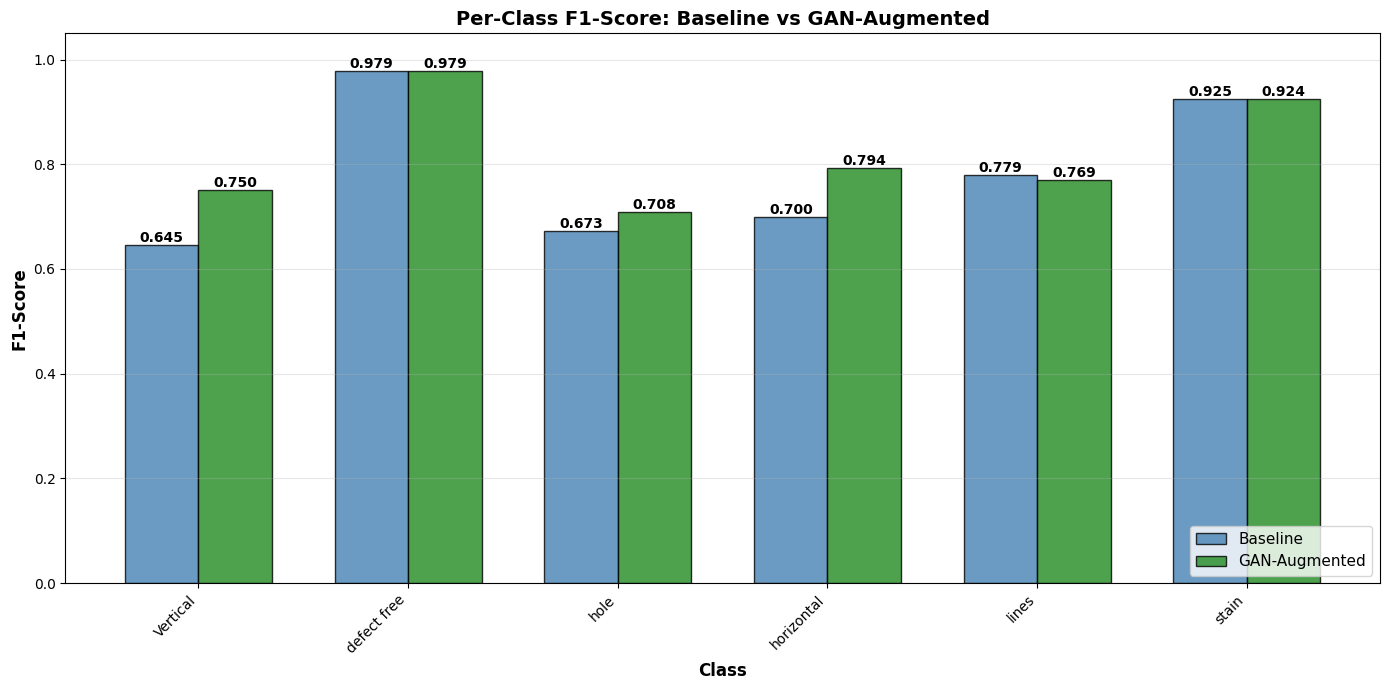


✓ Per-class comparison visualization saved


In [38]:
# Get per-class metrics for GAN model
precision_gan, recall_gan, f1_gan, support_gan = precision_recall_fscore_support(
    y_test_encoded, y_pred_gan
)

results_df_gan = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_gan,
    'Recall': recall_gan,
    'F1-Score': f1_gan,
    'Support': support_gan
})

# Create per-class comparison
per_class_comparison = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Baseline_F1': results_df_baseline['F1-Score'].values,
    'GAN_F1': results_df_gan['F1-Score'].values,
    'Support': results_df_baseline['Support'].values
})

per_class_comparison['Improvement'] = per_class_comparison['GAN_F1'] - per_class_comparison['Baseline_F1']
per_class_comparison['Improvement_%'] = (
    per_class_comparison['Improvement'] / per_class_comparison['Baseline_F1'] * 100
).round(2)

print("\nPER-CLASS F1-SCORE COMPARISON")
print("=" * 90)
print(per_class_comparison.to_string(index=False))
print("=" * 90)

# Save
per_class_comparison.to_csv('results/per_class_comparison.csv', index=False)

# Visualize
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(label_encoder.classes_))
width = 0.35

bars1 = ax.bar(x - width/2, per_class_comparison['Baseline_F1'],
               width, label='Baseline', color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, per_class_comparison['GAN_F1'],
               width, label='GAN-Augmented', color='forestgreen', edgecolor='black', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1-Score: Baseline vs GAN-Augmented', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('results/per_class_f1_comparison.png', dpi=300)
plt.show()

print("\n✓ Per-class comparison visualization saved")

## 7.4: Confusion Matrix Comparison

Visualize confusion matrices for both models side-by-side.

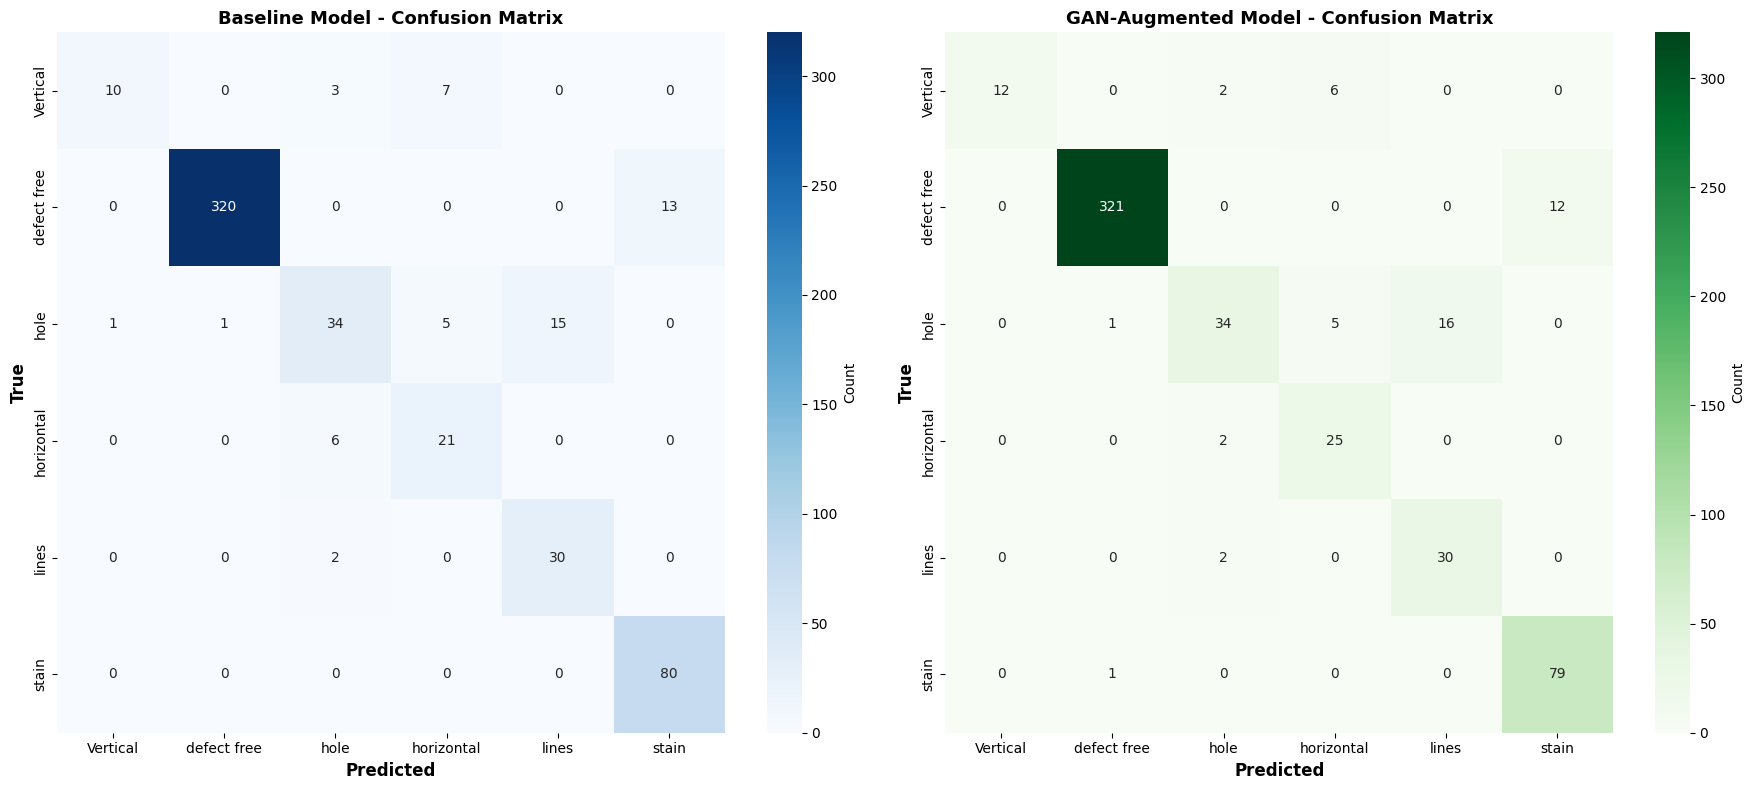

✓ Confusion matrices comparison saved


In [39]:
# Calculate confusion matrix for GAN model
cm_gan = confusion_matrix(y_test_encoded, y_pred_gan)

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'}, vmin=0)
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('True', fontsize=12, fontweight='bold')
ax1.set_title('Baseline Model - Confusion Matrix', fontsize=13, fontweight='bold')

# GAN-Augmented
sns.heatmap(cm_gan, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'}, vmin=0)
ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax2.set_ylabel('True', fontsize=12, fontweight='bold')
ax2.set_title('GAN-Augmented Model - Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/confusion_matrices_comparison.png', dpi=300)
plt.show()

print("✓ Confusion matrices comparison saved")

## 7.5: Statistical Significance Testing

Perform bootstrap testing to determine if improvements are statistically significant.

Performing bootstrap statistical significance testing...
This may take a moment...

STATISTICAL SIGNIFICANCE TEST (Bootstrap with 1000 iterations)
Baseline F1 Distribution:
  Mean: 0.7798, Std: 0.0299
  95% CI: [0.7210, 0.8362]

GAN-Augmented F1 Distribution:
  Mean: 0.8190, Std: 0.0255
  95% CI: [0.7700, 0.8662]

Paired t-test:
  t-statistic: 31.7961
  p-value: 0.000000

✓ The improvement IS STATISTICALLY SIGNIFICANT (p < 0.05)


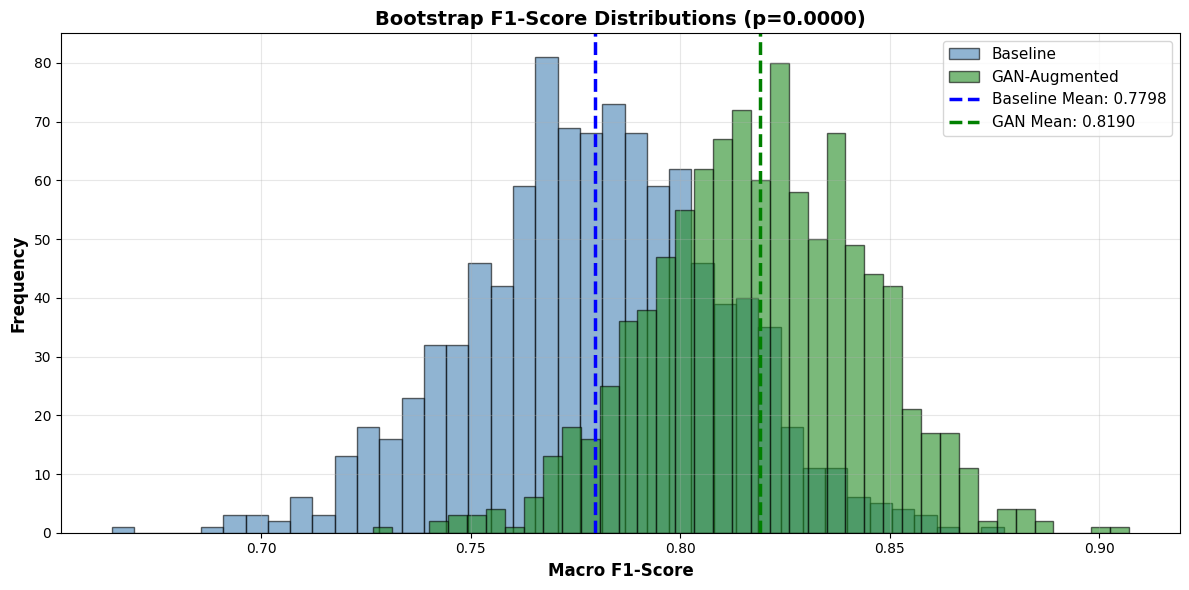


✓ Statistical test visualization saved


In [40]:
from scipy import stats

def bootstrap_f1_score(y_true, y_pred, n_iterations=1000):
    """Calculate bootstrap F1 scores"""
    scores = []
    n = len(y_true)

    for _ in range(n_iterations):
        # Sample with replacement
        indices = np.random.choice(n, n, replace=True)
        sample_true = y_true[indices]
        sample_pred = y_pred[indices]

        # Calculate macro F1
        f1 = f1_score(sample_true, sample_pred, average='macro')
        scores.append(f1)

    return np.array(scores)

print("Performing bootstrap statistical significance testing...")
print("This may take a moment...")

# Bootstrap both models
baseline_f1_dist = bootstrap_f1_score(y_test_encoded, y_pred_baseline, n_iterations=1000)
gan_f1_dist = bootstrap_f1_score(y_test_encoded, y_pred_gan, n_iterations=1000)

# Paired t-test
t_stat, p_value = stats.ttest_rel(gan_f1_dist, baseline_f1_dist)

print("\n" + "=" * 70)
print("STATISTICAL SIGNIFICANCE TEST (Bootstrap with 1000 iterations)")
print("=" * 70)
print(f"Baseline F1 Distribution:")
print(f"  Mean: {baseline_f1_dist.mean():.4f}, Std: {baseline_f1_dist.std():.4f}")
print(f"  95% CI: [{np.percentile(baseline_f1_dist, 2.5):.4f}, {np.percentile(baseline_f1_dist, 97.5):.4f}]")
print(f"\nGAN-Augmented F1 Distribution:")
print(f"  Mean: {gan_f1_dist.mean():.4f}, Std: {gan_f1_dist.std():.4f}")
print(f"  95% CI: [{np.percentile(gan_f1_dist, 2.5):.4f}, {np.percentile(gan_f1_dist, 97.5):.4f}]")
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"\n✓ The improvement IS STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"\n✗ The improvement is NOT statistically significant (p >= 0.05)")
print("=" * 70)

# Visualize distributions
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(baseline_f1_dist, bins=40, alpha=0.6, label='Baseline', color='steelblue', edgecolor='black')
ax.hist(gan_f1_dist, bins=40, alpha=0.6, label='GAN-Augmented', color='forestgreen', edgecolor='black')
ax.axvline(baseline_f1_dist.mean(), color='blue', linestyle='--', linewidth=2.5, label=f'Baseline Mean: {baseline_f1_dist.mean():.4f}')
ax.axvline(gan_f1_dist.mean(), color='green', linestyle='--', linewidth=2.5, label=f'GAN Mean: {gan_f1_dist.mean():.4f}')
ax.set_xlabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Bootstrap F1-Score Distributions (p={p_value:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/statistical_test.png', dpi=300)
plt.show()

print("\n✓ Statistical test visualization saved")

## 7.6: Generate Final Comprehensive Report

Create a detailed JSON report with all findings and metrics.

In [41]:
# Comprehensive final report
final_report = {
    'experiment_name': 'Fabric Defect Detection with GAN-based Data Augmentation',
    'date': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'framework': 'PyTorch',

    'dataset': {
        'total_images': len(all_files),
        'num_classes': num_classes,
        'class_names': label_encoder.classes_.tolist(),
        'original_imbalance_ratio': f"{max_count/min_count:.2f}:1",
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'augmented_train_samples': len(X_train_augmented),
        'synthetic_samples_added': len(X_train_augmented) - len(X_train)
    },

    'baseline_model': {
        'architecture': 'ResNet50 Transfer Learning',
        'training_epochs': len(history['train_loss']),
        'device': str(device),
        'metrics': {
            'overall_accuracy': float(accuracy_baseline),
            'macro_precision': float(precision_macro_baseline),
            'macro_recall': float(recall_macro_baseline),
            'macro_f1_score': float(f1_macro_baseline)
        },
        'per_class_metrics': results_df_baseline.to_dict('records')
    },

    'gan_configuration': {
        'architecture': 'DCGAN',
        'generator_latent_dim': latent_dim,
        'training_epochs': 300,
        'batch_size': 16,
        'defect_classes_augmented': defect_classes,
        'augmentation_ratio': '2x per class'
    },

    'gan_augmented_model': {
        'architecture': 'ResNet50 Transfer Learning',
        'training_epochs': len(history_gan['train_loss']),
        'device': str(device),
        'metrics': {
            'overall_accuracy': float(accuracy_gan),
            'macro_precision': float(precision_macro_gan),
            'macro_recall': float(recall_macro_gan),
            'macro_f1_score': float(f1_macro_gan)
        },
        'per_class_metrics': results_df_gan.to_dict('records')
    },

    'improvements': {
        'accuracy_improvement': float(accuracy_gan - accuracy_baseline),
        'accuracy_improvement_percent': float((accuracy_gan - accuracy_baseline) / accuracy_baseline * 100),
        'f1_score_improvement': float(f1_macro_gan - f1_macro_baseline),
        'f1_score_improvement_percent': float((f1_macro_gan - f1_macro_baseline) / f1_macro_baseline * 100)
    },

    'statistical_significance': {
        'test_type': 'Paired t-test (Bootstrap)',
        'bootstrap_iterations': 1000,
        'baseline_f1_mean': float(baseline_f1_dist.mean()),
        'baseline_f1_std': float(baseline_f1_dist.std()),
        'gan_f1_mean': float(gan_f1_dist.mean()),
        'gan_f1_std': float(gan_f1_dist.std()),
        't_statistic': float(t_stat),
        'p_value': float(p_value),
        'is_significant': bool(p_value < 0.05),
        'significance_level': '0.05'
    },

    'per_class_improvements': per_class_comparison.to_dict('records'),

    'key_findings': [
        f"Overall accuracy improved by {(accuracy_gan - accuracy_baseline) / accuracy_baseline * 100:.2f}%",
        f"Macro F1-score improved by {(f1_macro_gan - f1_macro_baseline) / f1_macro_baseline * 100:.2f}%",
        f"Improvement is {'statistically significant' if p_value < 0.05 else 'not statistically significant'} (p={p_value:.6f})",
        f"Best improvement for class: {per_class_comparison.loc[per_class_comparison['Improvement_%'].idxmax(), 'Class']} "
        f"({per_class_comparison['Improvement_%'].max():.2f}% F1-score improvement)"
    ]
}

# Save report
with open('results/final_report.json', 'w') as f:
    json.dump(final_report, f, indent=4)

# Print summary
print("\n" + "=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)
print(f"Dataset: {len(all_files)} images across {num_classes} classes")
print(f"Original imbalance: {max_count/min_count:.2f}:1")
print(f"Synthetic data augmentation: {len(X_train_augmented) - len(X_train)} images generated")
print(f"\nBaseline Model F1-Score:        {f1_macro_baseline:.4f}")
print(f"GAN-Augmented Model F1-Score:   {f1_macro_gan:.4f}")
print(f"Improvement:                    +{f1_macro_gan - f1_macro_baseline:.4f} ({(f1_macro_gan - f1_macro_baseline) / f1_macro_baseline * 100:.2f}%)")
print(f"Statistical Significance:       p={p_value:.6f} {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ NOT SIGNIFICANT'}")
print("=" * 80)
print("\n✓ Final report saved to results/final_report.json")
print("\nAll results files saved in 'results/' directory:")
print("  - baseline_training_history.png")
print("  - training_comparison.png")
print("  - per_class_f1_comparison.png")
print("  - confusion_matrices_comparison.png")
print("  - statistical_test.png")
print("  - baseline_classification_report.txt")
print("  - baseline_per_class_metrics.csv")
print("  - per_class_comparison.csv")
print("  - model_comparison.csv")
print("  - final_report.json")


FINAL PROJECT SUMMARY
Dataset: 2739 images across 6 classes
Original imbalance: 16.50:1
Synthetic data augmentation: 1288 images generated

Baseline Model F1-Score:        0.7835
GAN-Augmented Model F1-Score:   0.8206
Improvement:                    +0.0371 (4.74%)
Statistical Significance:       p=0.000000 ✓ SIGNIFICANT

✓ Final report saved to results/final_report.json

All results files saved in 'results/' directory:
  - baseline_training_history.png
  - training_comparison.png
  - per_class_f1_comparison.png
  - confusion_matrices_comparison.png
  - statistical_test.png
  - baseline_classification_report.txt
  - baseline_per_class_metrics.csv
  - per_class_comparison.csv
  - model_comparison.csv
  - final_report.json
